In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor

(35.0, 50.0)

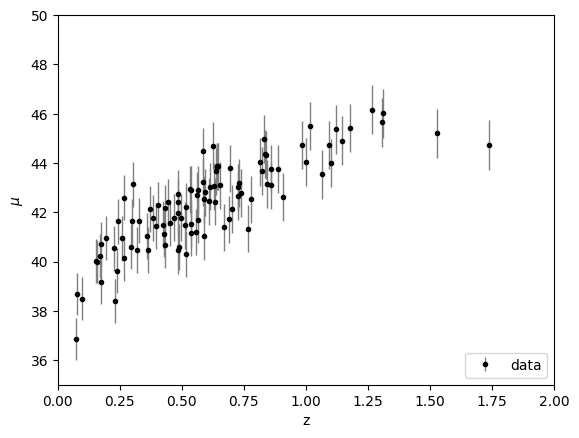

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [3]:
kernel = RBF(0.5, (0.01, 10.0))
gp = GaussianProcessRegressor(kernel=kernel,
                               alpha=dmu ** 2)
x = np.linspace(0,2,100)
gp.fit(z_sample[:, None], mu_sample)
mu_fitted, sigma_fit = gp.predict(x[:, None], 
                         return_std=True)

# we have fit for the `h` parameter: print the result here:
print("best-fit theta =", gp.kernel_.theta[0])

best-fit theta = 0.9225046869266914


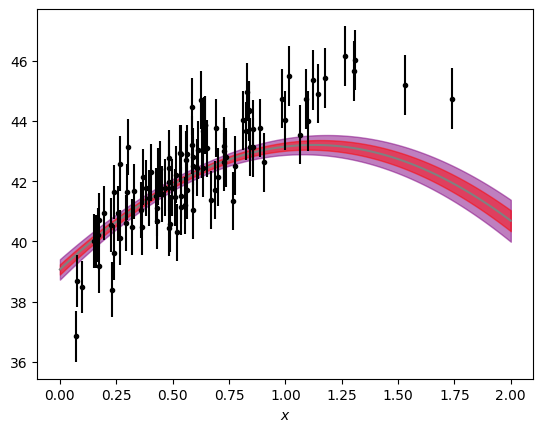

In [4]:
fig, ax = plt.subplots()
ax.plot(x, mu_fitted, '-', color='gray')
ax.fill_between(x, mu_fitted - 2* sigma_fit, mu_fitted + 2 * sigma_fit, alpha=0.5,
                color='purple', 
                label='2-$\sigma$ level')
ax.fill_between(x, mu_fitted -  sigma_fit, mu_fitted +  sigma_fit, alpha=0.5,
                color='red', 
                label='1-$\sigma$ level')
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ms=6)

ax.set_xlabel('$x$')


plt.show()

In [5]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# parameters grid
l_range = np.linspace(0.01,10)
k = 8
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_errors_gpr = []

for l in l_range:
    v_err = []
    # kernel fixed for internal iterations
    kernel = RBF(length_scale=l)
    
    for train_idx, val_idx in kf.split(z_sample):
        z_tr, z_vl = z_sample[train_idx, np.newaxis], z_sample[val_idx, np.newaxis]
        mu_tr, mu_vl = mu_sample[train_idx], mu_sample[val_idx]
        dmu_tr = dmu[train_idx]
        
        gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu_tr**2, optimizer=None)
        gp.fit(z_tr, mu_tr)
        
        y_pred = gp.predict(z_vl)
        v_err.append(mean_squared_error(mu_vl, y_pred))
        
    cv_errors_gpr.append(np.mean(v_err))


best_l = l_range[np.argmin(cv_errors_gpr)]
print(f"Best length_scale: {best_l:.3f}")

Best length_scale: 2.253


Text(0.5, 1.0, 'GPR best fit (l=2.25)')

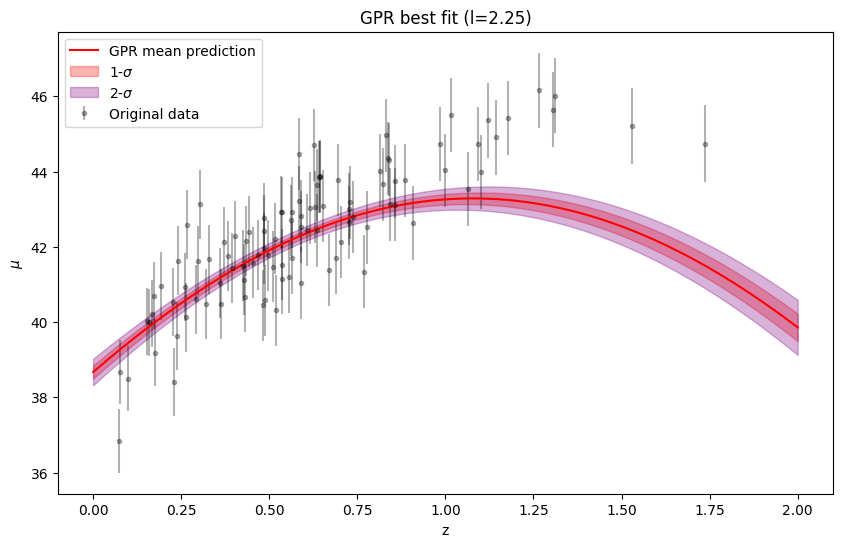

In [6]:
best_kernel = RBF(length_scale=best_l)
gp_final = GaussianProcessRegressor(kernel=best_kernel, alpha=dmu**2, optimizer=None)
gp_final.fit(z_sample[:, np.newaxis], mu_sample)

z = np.linspace(0, 2, 200)[:, np.newaxis]
mu_pred, sigma_pred = gp_final.predict(z, return_std=True)

plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', alpha=0.3, label='Original data')
plt.plot(z, mu_pred, 'r-', label='GPR mean prediction')


plt.fill_between(z.flatten(), mu_pred - sigma_pred, mu_pred + sigma_pred, color='red', alpha=0.3, label=r'1-$\sigma$')
plt.fill_between(z.flatten(), mu_pred - 2*sigma_pred, mu_pred + 2*sigma_pred, color='purple', alpha=0.3, label=r'2-$\sigma$')

plt.xlabel('z')
plt.ylabel('$\mu$')
plt.legend()
plt.title(f"GPR best fit (l={best_l:.2f})")

In [7]:

from sklearn.gaussian_process.kernels import  ConstantKernel as C


c_range = np.logspace(-1, 5, 10)  # Amplitude
l_range = np.logspace(-2, 3, 10) # scale

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)


grid_errors = np.zeros((len(c_range), len(l_range)))

for i, c_val in enumerate(c_range):
    for j, l_val in enumerate(l_range):
        v_err = []
        kernel = C(c_val) * RBF(length_scale=l_val)
        
        for train_idx, val_idx in kf.split(z_sample):
            z_tr, z_vl = z_sample[train_idx, np.newaxis], z_sample[val_idx, np.newaxis]
            mu_tr, mu_vl = mu_sample[train_idx], mu_sample[val_idx]
            dmu_tr = dmu[train_idx]
            
            # optimizer=None 
            gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu_tr**2, optimizer=None)
            gp.fit(z_tr, mu_tr)
            
            y_pred = gp.predict(z_vl)
            v_err.append(mean_squared_error(mu_vl, y_pred))
            
        grid_errors[i, j] = np.mean(v_err)


idx_c, idx_l = np.unravel_index(np.argmin(grid_errors), grid_errors.shape)
best_c = c_range[idx_c]
best_l = l_range[idx_l]

print(f"Bets Constant C: {best_c:.2f}")
print(f"Best Length-scale l: {best_l:.2f}")

Bets Constant C: 215.44
Best Length-scale l: 1.67


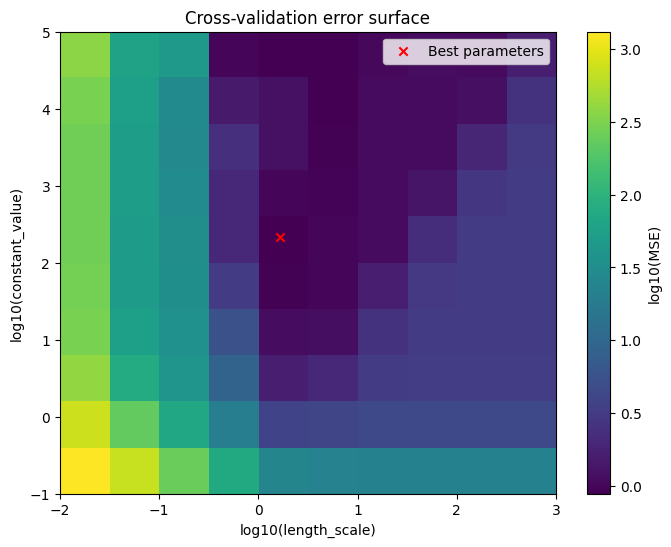

In [8]:
plt.figure(figsize=(8, 6))
plt.imshow(np.log10(grid_errors), extent=[np.log10(l_range.min()), np.log10(l_range.max()), 
                                          np.log10(c_range.min()), np.log10(c_range.max())],
           aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='log10(MSE)')
plt.scatter(np.log10(best_l), np.log10(best_c), color='red', marker='x', label='Best parameters')
plt.xlabel('log10(length_scale)')
plt.ylabel('log10(constant_value)')
plt.title('Cross-validation error surface')
plt.legend()
plt.show()

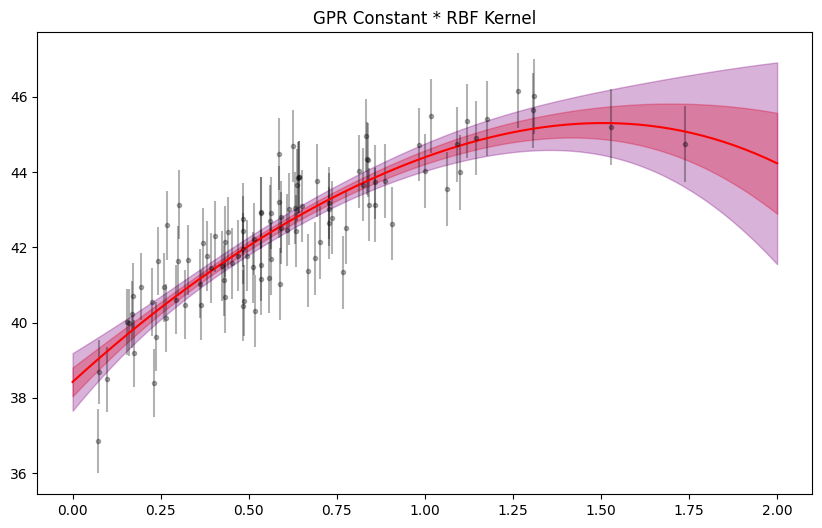

In [9]:
best_kernel = C(best_c) * RBF(length_scale=best_l)
gp_final = GaussianProcessRegressor(kernel=best_kernel, alpha=dmu**2, optimizer=None)
gp_final.fit(z_sample[:, np.newaxis], mu_sample)

z = np.linspace(0, 2, 200)[:, np.newaxis]
mu_pred, sigma_pred = gp_final.predict(z, return_std=True)

plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', alpha=0.3)
plt.plot(z, mu_pred, 'r-', label=f'GPR fit (C={best_c:.1f}, l={best_l:.2f})')
plt.fill_between(z.flatten(), mu_pred - sigma_pred, mu_pred + sigma_pred, color='red', alpha=0.3)
plt.fill_between(z.flatten(), mu_pred - 2*sigma_pred, mu_pred + 2*sigma_pred, color='purple', alpha=0.3)
plt.title("GPR Constant * RBF Kernel")
plt.show()

(array([12., 15., 24., 23., 11.,  5.,  5.,  3.,  1.,  1.]),
 array([0.07346547, 0.23986399, 0.40626252, 0.57266104, 0.73905956,
        0.90545809, 1.07185661, 1.23825513, 1.40465366, 1.57105218,
        1.7374507 ]),
 <BarContainer object of 10 artists>)

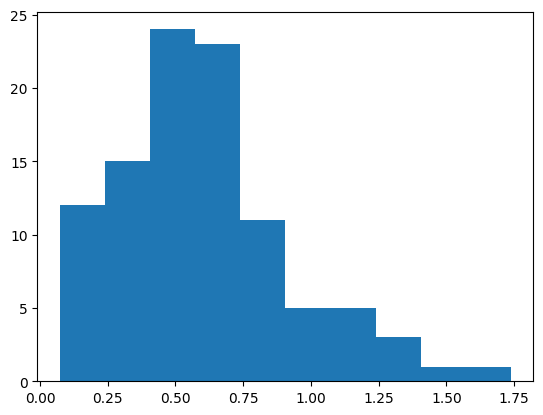

In [10]:
plt.hist(z_sample)

In [11]:
from sklearn.neighbors import KernelDensity

z_data = z_sample[:, np.newaxis]
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_data)


z_cloned = kde.sample(1000, random_state=42)
z_cloned = np.sort(z_cloned, axis=0) 

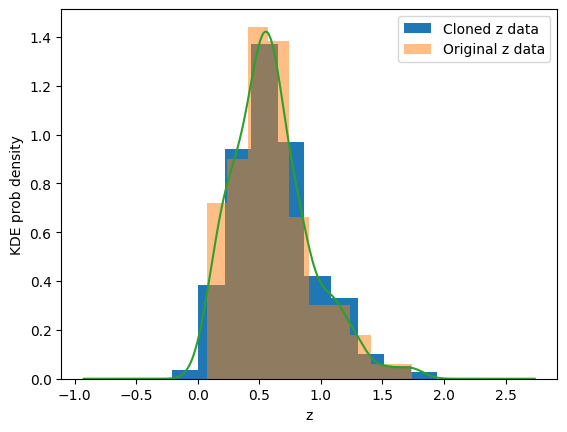

In [16]:
plt.hist(z_cloned, density=True, label= 'Cloned z data')
plt.hist(z_sample, density=True, alpha =0.5, label= 'Original z data')
z_ax = np.linspace(z_data.min() - 1, z_data.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_ax)

plt.plot(z_ax[:, 0], np.exp(log_dens))
plt.xlabel('z')
plt.ylabel('KDE prob density')
plt.legend()
plt.show()

In [21]:

mu_mean, mu_sigma = gp_final.predict(z_cloned, return_std = True)
cloned_mu = np.random.normal(loc=mu_mean,scale=mu_sigma)

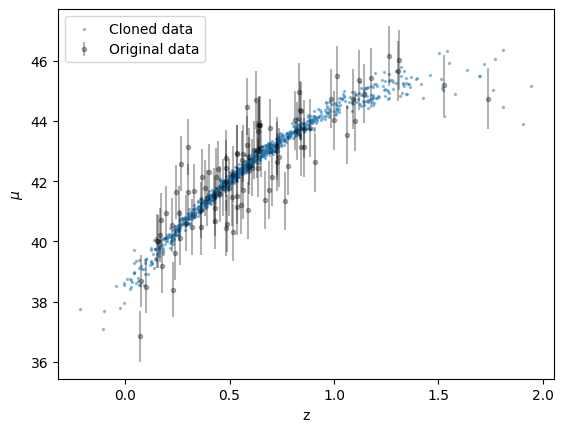

In [24]:
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', alpha=0.3, label ='Original data')
plt.scatter(z_cloned, cloned_mu, s=2, alpha=0.4, label ='Cloned data')

plt.xlabel('z')
plt.ylabel('$\mu$')
plt.legend()


In [25]:
import emcee
import scipy.integrate as integrate

c = 299792.458 # km/s

def mu_model(z, h0, om):
    # integrand E(z)
    def Ez(z_prime, om):
        return 1.0 / np.sqrt(om * (1 + z_prime)**3 + (1 - om))
    
    # integral of comoving distance
    integral, _ = integrate.quad(Ez, 0, z, args=(om))
    dl = (1 + z) * (c / h0) * integral
    return 5 * np.log10(dl) + 25


mu_model_v = np.vectorize(mu_model)

def log_prior(theta):
    h0, om = theta
    if 50.0 < h0 < 100.0 and 0.0 < om < 1.0:
        return 0.0 # Prior flat
    return -np.inf

def log_likelihood(theta, z, mu, dmu):
    h0, om = theta
    model = mu_model_v(z, h0, om)
    sigma2 = dmu**2
    return -0.5 * np.sum((mu - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_probability(theta, z, mu, dmu):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, dmu)

In [27]:
# Inizializzazione
initial = np.array([70, 0.3])
nwalkers, ndim = 32, 2
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z_sample, mu_sample, dmu))

# Burn-in e produzione
print("Running MCMC...")
sampler.run_mcmc(pos, 2000, progress=True);

You must install the tqdm library to use progress indicators with emcee


Running MCMC...
emcee: Exception while calling your likelihood function:
  params: [63.22730002  0.66566975]
  args: (array([0.29907871, 0.64057897, 0.48439381, 0.83200371, 0.82408678,
       0.36113938, 0.36402348, 0.8573685 , 1.30588524, 0.99995019,
       0.42423046, 0.53429221, 0.70331746, 0.73642792, 0.43346403,
       0.58487846, 0.5359888 , 0.09800896, 0.81381534, 1.01633991,
       0.42947624, 0.63416305, 0.1935354 , 0.43240289, 1.17731844,
       0.66951722, 0.45360888, 0.8370468 , 0.39392919, 0.59093132,
       0.98410959, 0.48319916, 0.8578064 , 0.25959377, 0.72661499,
       0.72698343, 0.32043128, 1.14459622, 0.48779261, 1.09114495,
       0.17527352, 0.29329624, 0.15899309, 0.69403869, 0.61477425,
       0.56098838, 0.1532864 , 0.58508523, 0.40340699, 0.53589418,
       0.23081645, 0.62642515, 0.58903611, 0.07571118, 0.63611004,
       1.10014003, 0.83975753, 1.7374507 , 1.31019458, 0.84194741,
       0.37055496, 0.64328593, 0.51591245, 0.3023762 , 0.44245798,
       0.16

Traceback (most recent call last):
  File "C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\annat\AppData\Local\Temp\ipykernel_10596\3561790160.py", line 35, in log_probability
    return lp + log_likelihood(theta, z, mu, dmu)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\annat\AppData\Local\Temp\ipykernel_10596\3561790160.py", line 27, in log_likelihood
    model = mu_model_v(z, h0, om)
            ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\numpy\lib\_function_base_impl.py", line 2518, in __call__
    return self._call_as_normal(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\numpy\lib\_function_base_impl.py", line 2511, in _call_as_normal
    return self._vectorize_call(func=

KeyboardInterrupt: 

In [ ]:
import corner

samples = sampler.get_chain(discard=500, thin=15, flat=True)
fig = corner.corner(samples, labels=["$H_0$", "$\Omega_m$"], truths=[70, 0.3])

# Mediana e incertezze (68% CL)
h0_mcmc, om_mcmc = np.median(samples, axis=0)
h0_std, om_std = np.std(samples, axis=0)

print(f"H0 measured: {h0_mcmc:.2f} +/- {h0_std:.2f}")
print(f"Omega_m measured: {om_mcmc:.3f} +/- {om_std:.3f}")

In [ ]:
# Likelihood of none DE model (fix om=1)
log_L_no_DE = log_likelihood([h0_mcmc, 1.0], z_sample, mu_sample, dmu)
log_L_LCDM = log_likelihood([h0_mcmc, om_mcmc], z_sample, mu_sample, dmu)

bic_LCDM = 2 * np.log(len(z_sample)) - 2 * log_L_LCDM
bic_no_DE = 1 * np.log(len(z_sample)) - 2 * log_L_no_DE

delta_bic = bic_no_DE - bic_LCDM
print(f"Delta BIC: {delta_bic:.2f}")